In [6]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import numpy as np
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [7]:
# Oxford-IIIT Pet Dataset — 37 cat & dog breeds (~7,400 images)
DATA_DIR = './data'

# Download both splits
trainval_raw = datasets.OxfordIIITPet(root=DATA_DIR, split='trainval', download=True)
test_raw     = datasets.OxfordIIITPet(root=DATA_DIR, split='test',     download=True)

CLASS_NAMES = trainval_raw.classes
NUM_CLASSES = len(CLASS_NAMES)
print(f'Trainval images : {len(trainval_raw)}')
print(f'Test images     : {len(test_raw)}')
print(f'Number of classes: {NUM_CLASSES}')

100%|██████████| 792M/792M [00:27<00:00, 28.4MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 13.2MB/s]


Trainval images : 3680
Test images     : 3669
Number of classes: 37


In [8]:
print('All 37 pet breeds:')
for i, name in enumerate(CLASS_NAMES):
    print(f'  [{i:02d}] {name}')

All 37 pet breeds:
  [00] Abyssinian
  [01] American Bulldog
  [02] American Pit Bull Terrier
  [03] Basset Hound
  [04] Beagle
  [05] Bengal
  [06] Birman
  [07] Bombay
  [08] Boxer
  [09] British Shorthair
  [10] Chihuahua
  [11] Egyptian Mau
  [12] English Cocker Spaniel
  [13] English Setter
  [14] German Shorthaired
  [15] Great Pyrenees
  [16] Havanese
  [17] Japanese Chin
  [18] Keeshond
  [19] Leonberger
  [20] Maine Coon
  [21] Miniature Pinscher
  [22] Newfoundland
  [23] Persian
  [24] Pomeranian
  [25] Pug
  [26] Ragdoll
  [27] Russian Blue
  [28] Saint Bernard
  [29] Samoyed
  [30] Scottish Terrier
  [31] Shiba Inu
  [32] Siamese
  [33] Sphynx
  [34] Staffordshire Bull Terrier
  [35] Wheaten Terrier
  [36] Yorkshire Terrier


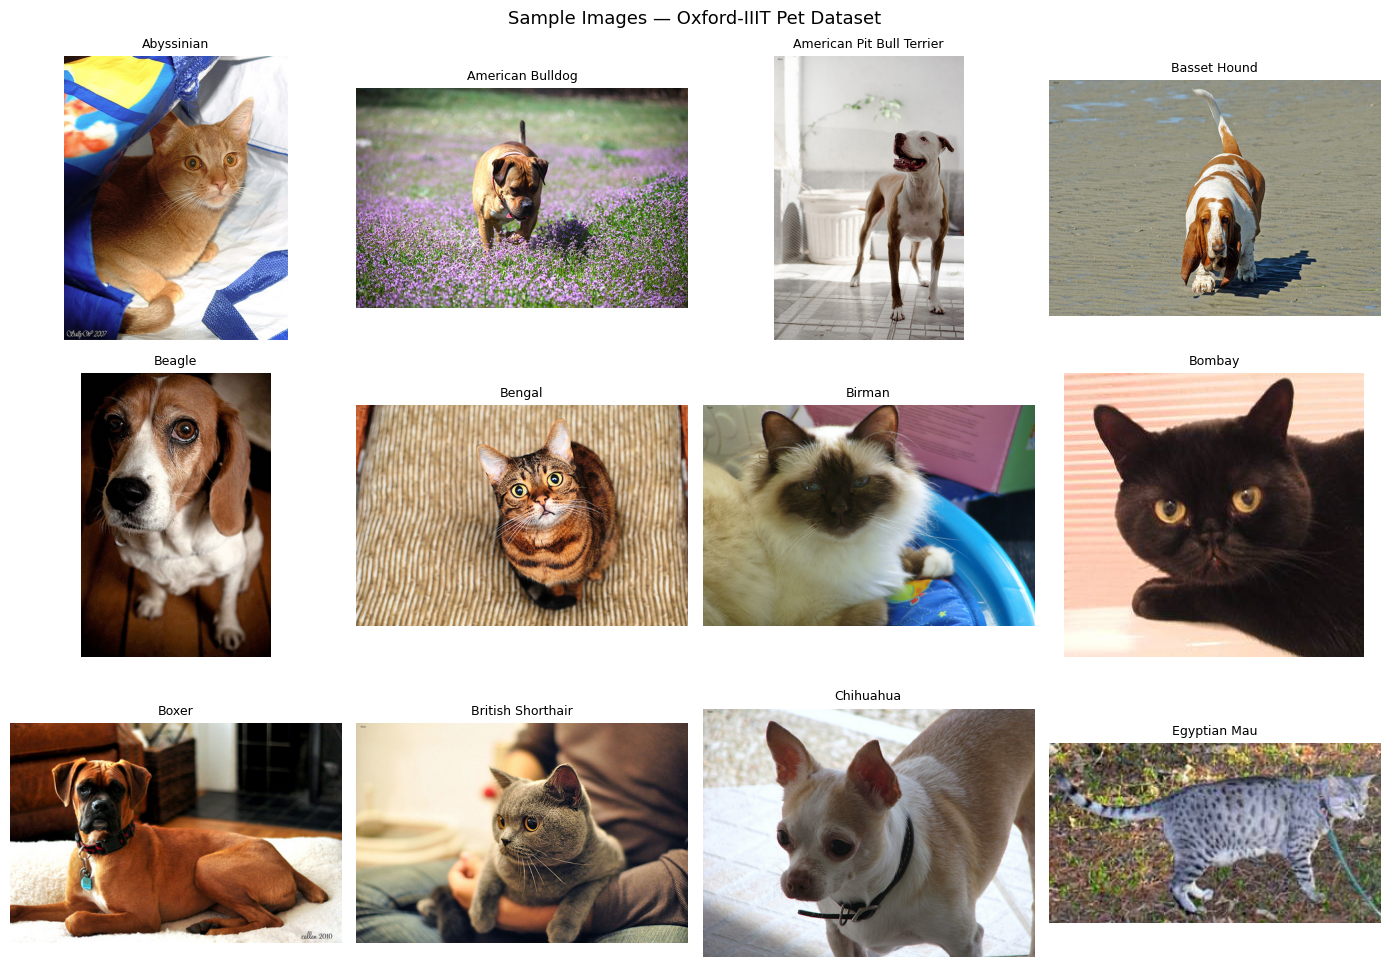

In [9]:
# Show one sample image per class (first 12 classes)
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

seen = {}
for img, label in trainval_raw:
    if label not in seen:
        seen[label] = img
    if len(seen) == 12:
        break

for idx, (label, img) in enumerate(sorted(seen.items())):
    axes[idx].imshow(img)
    axes[idx].set_title(CLASS_NAMES[label], fontsize=9)
    axes[idx].axis('off')

plt.suptitle('Sample Images — Oxford-IIIT Pet Dataset', fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
# Important Hyperparameters
IMG_SIZE            = 128   # input resolution
batch_size          = 32
learning_rate       = 0.001
minimum_learning_rate = 1e-5
epochs              = 25

In [11]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),       # flip augmentation
    transforms.RandomRotation(15),            # rotate ±15 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [12]:
# Wrapper to apply different transforms to train / val subsets
class TransformDataset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset    = subset
        self.transform = transform
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label
    def __len__(self):
        return len(self.subset)

# 80 / 20 split of trainval
base_dataset = datasets.OxfordIIITPet(root=DATA_DIR, split='trainval', download=False)
total      = len(base_dataset)
train_size = int(0.8 * total)
val_size   = total - train_size
train_sub, val_sub = random_split(base_dataset, [train_size, val_size],
                                   generator=torch.Generator().manual_seed(42))

train_data = TransformDataset(train_sub, train_transform)
val_data   = TransformDataset(val_sub,   val_transform)
test_data  = datasets.OxfordIIITPet(root=DATA_DIR, split='test',
                                     download=False, transform=val_transform)
print(f'Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}')

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

Train: 2944, Val: 736, Test: 3669


In [13]:
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchsummary import summary

# ── Model 1: Base CNN (without BatchNorm / Dropout) ──────────────────────
class PetCNN(nn.Module):
    def __init__(self, num_classes=37):
        super(PetCNN, self).__init__()

        self.conv_layers = nn.Sequential(
            # Block 1: 128x128 → 64x64
            nn.Conv2d(3,   32,  kernel_size=3, padding=1),
            nn.ReLU(), nn.MaxPool2d(2),
            # Block 2: 64x64  → 32x32
            nn.Conv2d(32,  64,  kernel_size=3, padding=1),
            nn.ReLU(), nn.MaxPool2d(2),
            # Block 3: 32x32  → 16x16
            nn.Conv2d(64,  128, kernel_size=3, padding=1),
            nn.ReLU(), nn.MaxPool2d(2),
            # Block 4: 16x16  → 8x8
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(), nn.MaxPool2d(2),
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# 1. Get the model
model     = PetCNN(num_classes=NUM_CLASSES).to(device)
# 2. Define optimizer
optimizer = Adam(model.parameters(), lr=learning_rate)
# 3. Define LR scheduler
scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=minimum_learning_rate)
# 4. Define loss function
criterion = nn.CrossEntropyLoss()

print('=== Base CNN (no BatchNorm / Dropout) ===')
summary(model, input_size=(3, IMG_SIZE, IMG_SIZE));

=== Base CNN (no BatchNorm / Dropout) ===
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
              ReLU-2         [-1, 32, 128, 128]               0
         MaxPool2d-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
              ReLU-5           [-1, 64, 64, 64]               0
         MaxPool2d-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
              ReLU-8          [-1, 128, 32, 32]               0
         MaxPool2d-9          [-1, 128, 16, 16]               0
           Conv2d-10          [-1, 256, 16, 16]         295,168
             ReLU-11          [-1, 256, 16, 16]               0
        MaxPool2d-12            [-1, 256, 8, 8]               0
          Flatten-13                [-1, 16384]              

In [14]:
# ── Model 2: Regularized CNN (with BatchNorm + Dropout) ─────────────────
class PetCNN_Regularized(nn.Module):
    def __init__(self, num_classes=37):
        super(PetCNN_Regularized, self).__init__()

        self.conv_layers = nn.Sequential(
            # Block 1: 128x128 → 64x64
            nn.Conv2d(3,   32,  kernel_size=3, padding=1),
            nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),
            # Block 2: 64x64  → 32x32
            nn.Conv2d(32,  64,  kernel_size=3, padding=1),
            nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            # Block 3: 32x32  → 16x16
            nn.Conv2d(64,  128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            # Block 4: 16x16  → 8x8
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

model_reg     = PetCNN_Regularized(num_classes=NUM_CLASSES).to(device)
optimizer_reg = Adam(model_reg.parameters(), lr=learning_rate)
scheduler_reg = CosineAnnealingLR(optimizer_reg, T_max=epochs, eta_min=minimum_learning_rate)
criterion_reg = nn.CrossEntropyLoss()

print('=== Regularized CNN (BatchNorm + Dropout) ===')
summary(model_reg, input_size=(3, IMG_SIZE, IMG_SIZE));

=== Regularized CNN (BatchNorm + Dropout) ===
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
       BatchNorm2d-2         [-1, 32, 128, 128]              64
              ReLU-3         [-1, 32, 128, 128]               0
         MaxPool2d-4           [-1, 32, 64, 64]               0
            Conv2d-5           [-1, 64, 64, 64]          18,496
       BatchNorm2d-6           [-1, 64, 64, 64]             128
              ReLU-7           [-1, 64, 64, 64]               0
         MaxPool2d-8           [-1, 64, 32, 32]               0
            Conv2d-9          [-1, 128, 32, 32]          73,856
      BatchNorm2d-10          [-1, 128, 32, 32]             256
             ReLU-11          [-1, 128, 32, 32]               0
        MaxPool2d-12          [-1, 128, 16, 16]               0
           Conv2d-13          [-1, 256, 16, 16]         2

In [15]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct    = 0
    total      = 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss    = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct  += (preds == labels).sum().item()
        total    += labels.size(0)

    train_loss = total_loss / len(loader)
    train_acc  = correct / total
    return train_loss, train_acc


def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct    = 0
    total      = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss    = criterion(outputs, labels)

            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct  += (preds == labels).sum().item()
            total    += labels.size(0)

    val_loss = total_loss / len(loader)
    val_acc  = correct / total
    return val_loss, val_acc

In [16]:
# ── Train Base CNN ───────────────────────────────────────────────────────
train_losses, train_accuracies = [], []
val_losses,   val_accuracies   = [], []

for epoch in range(epochs):
    print('----------------------------------------------------')
    print(f"Epoch {epoch+1}/{epochs}, LR: {optimizer.param_groups[0]['lr']:.6g}")

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss,   val_acc   = validate_epoch(model, val_loader, criterion, device)
    scheduler.step()

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}')
    print(f'Val   Loss: {val_loss:.4f}   | Val   Acc: {val_acc:.4f}')

----------------------------------------------------
Epoch 1/25, LR: 0.001
Train Loss: 3.6142 | Train Acc: 0.0228
Val   Loss: 3.6104   | Val   Acc: 0.0299
----------------------------------------------------
Epoch 2/25, LR: 0.000996097
Train Loss: 3.5497 | Train Acc: 0.0469
Val   Loss: 3.4743   | Val   Acc: 0.0476
----------------------------------------------------
Epoch 3/25, LR: 0.000984449
Train Loss: 3.4353 | Train Acc: 0.0628
Val   Loss: 3.4124   | Val   Acc: 0.0707
----------------------------------------------------
Epoch 4/25, LR: 0.000965239
Train Loss: 3.3780 | Train Acc: 0.0781
Val   Loss: 3.3607   | Val   Acc: 0.0774
----------------------------------------------------
Epoch 5/25, LR: 0.000938772
Train Loss: 3.3262 | Train Acc: 0.0859
Val   Loss: 3.3324   | Val   Acc: 0.0856
----------------------------------------------------
Epoch 6/25, LR: 0.000905463
Train Loss: 3.2619 | Train Acc: 0.1036
Val   Loss: 3.3029   | Val   Acc: 0.0870
----------------------------------------

In [17]:
# ── Train Regularized CNN ────────────────────────────────────────────────
train_losses_reg, train_accuracies_reg = [], []
val_losses_reg,   val_accuracies_reg   = [], []

for epoch in range(epochs):
    print('----------------------------------------------------')
    print(f"Epoch {epoch+1}/{epochs}, LR: {optimizer_reg.param_groups[0]['lr']:.6g}")

    train_loss, train_acc = train_epoch(model_reg, train_loader, optimizer_reg, criterion_reg, device)
    val_loss,   val_acc   = validate_epoch(model_reg, val_loader, criterion_reg, device)
    scheduler_reg.step()

    train_losses_reg.append(train_loss)
    train_accuracies_reg.append(train_acc)
    val_losses_reg.append(val_loss)
    val_accuracies_reg.append(val_acc)

    print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}')
    print(f'Val   Loss: {val_loss:.4f}   | Val   Acc: {val_acc:.4f}')

----------------------------------------------------
Epoch 1/25, LR: 0.001
Train Loss: 4.5504 | Train Acc: 0.0289
Val   Loss: 3.6106   | Val   Acc: 0.0245
----------------------------------------------------
Epoch 2/25, LR: 0.000996097
Train Loss: 3.6120 | Train Acc: 0.0279
Val   Loss: 3.6109   | Val   Acc: 0.0177
----------------------------------------------------
Epoch 3/25, LR: 0.000984449
Train Loss: 3.6113 | Train Acc: 0.0275
Val   Loss: 3.6123   | Val   Acc: 0.0177
----------------------------------------------------
Epoch 4/25, LR: 0.000965239
Train Loss: 3.6115 | Train Acc: 0.0296
Val   Loss: 3.6124   | Val   Acc: 0.0177
----------------------------------------------------
Epoch 5/25, LR: 0.000938772
Train Loss: 3.6116 | Train Acc: 0.0306
Val   Loss: 3.6134   | Val   Acc: 0.0177
----------------------------------------------------
Epoch 6/25, LR: 0.000905463
Train Loss: 3.6090 | Train Acc: 0.0296
Val   Loss: 3.6038   | Val   Acc: 0.0217
----------------------------------------

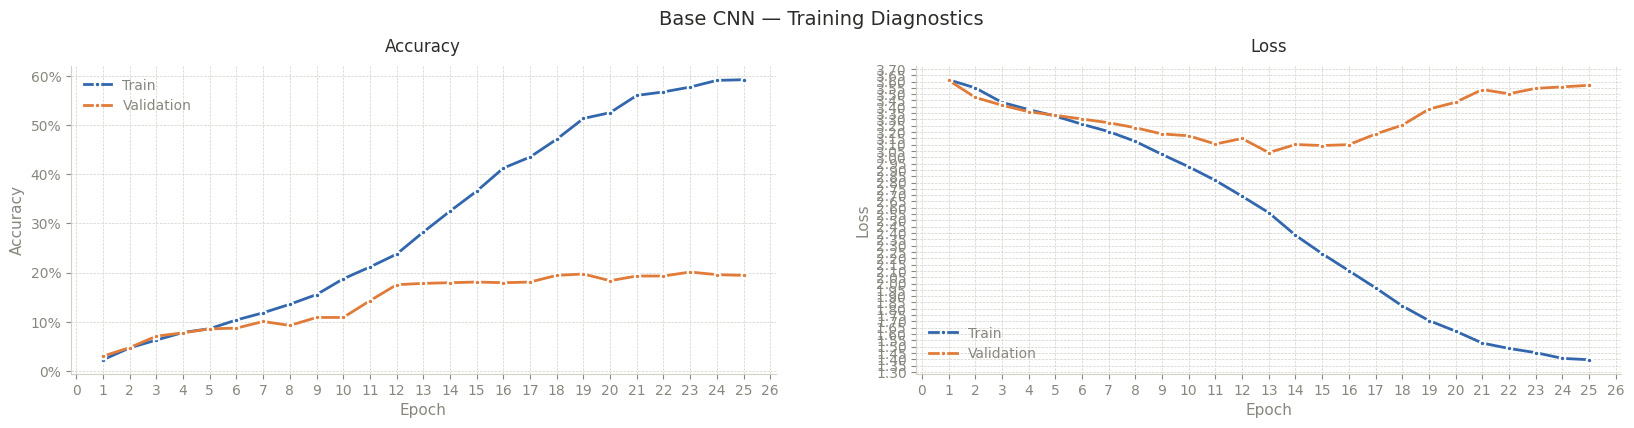

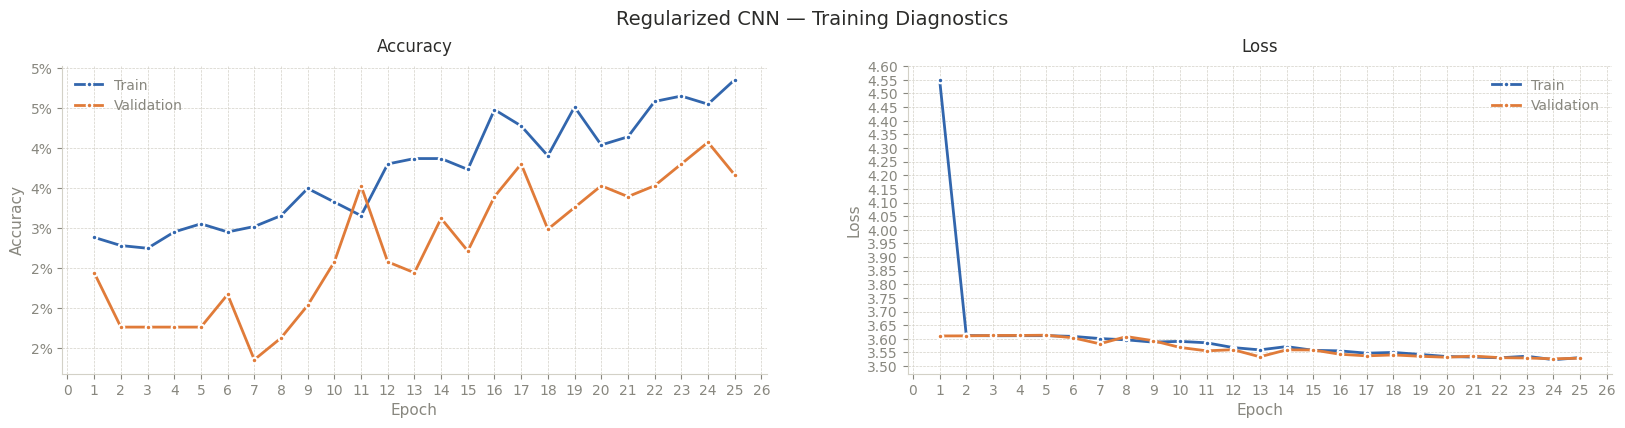

In [18]:
BLUE   = '#3266ad'
ORANGE = '#e07b39'
GRAY   = '#88877f'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#d3d1c7',
    'axes.linewidth': 0.8,
    'axes.grid': True,
    'grid.color': '#d3d1c7',
    'grid.linewidth': 0.5,
    'grid.linestyle': '--',
    'xtick.color': GRAY,
    'ytick.color': GRAY,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

epochs_x = np.arange(1, epochs + 1)

for title, t_acc, v_acc, t_loss, v_loss in [
    ('Base CNN',        train_accuracies,     val_accuracies,     train_losses,     val_losses),
    ('Regularized CNN', train_accuracies_reg, val_accuracies_reg, train_losses_reg, val_losses_reg),
]:
    fig = plt.figure(figsize=(20, 4))
    gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.2)

    ax1 = fig.add_subplot(gs[0])
    ax1.plot(epochs_x, t_acc, color=BLUE,   lw=2, label='Train',      marker='o', ms=4, mew=1.5, mec='white')
    ax1.plot(epochs_x, v_acc, color=ORANGE, lw=2, label='Validation', marker='o', ms=4, mew=1.5, mec='white')
    ax1.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
    ax1.set_xlabel('Epoch', color=GRAY, fontsize=11)
    ax1.set_ylabel('Accuracy', color=GRAY, fontsize=11)
    ax1.set_title('Accuracy', fontsize=12, fontweight='medium', color='#2c2c2a', pad=10)
    ax1.legend(frameon=False, fontsize=10, labelcolor=GRAY)

    ax2 = fig.add_subplot(gs[1])
    ax2.plot(epochs_x, t_loss, color=BLUE,   lw=2, label='Train',      marker='o', ms=4, mew=1.5, mec='white')
    ax2.plot(epochs_x, v_loss, color=ORANGE, lw=2, label='Validation', marker='o', ms=4, mew=1.5, mec='white')
    ax2.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax2.yaxis.set_major_locator(mticker.MultipleLocator(0.05))
    ax2.set_xlabel('Epoch', color=GRAY, fontsize=11)
    ax2.set_ylabel('Loss',  color=GRAY, fontsize=11)
    ax2.set_title('Loss', fontsize=12, fontweight='medium', color='#2c2c2a', pad=10)
    ax2.legend(frameon=False, fontsize=10, labelcolor=GRAY)

    fig.suptitle(f'{title} — Training Diagnostics', fontsize=14, fontweight='medium', color='#2c2c2a', y=1.02)
    plt.savefig(f'training_curves_{title.replace(" ", "_")}.pdf', bbox_inches='tight', dpi=150)
    plt.show()

In [19]:
# ── Evaluate best model (Regularized CNN) on test set ───────────────────
model_reg.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model_reg(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy  = (all_preds == all_labels).mean()
precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
recall    = recall_score(   all_labels, all_preds, average='macro', zero_division=0)
f1        = f1_score(       all_labels, all_preds, average='macro', zero_division=0)

print(f'Test Accuracy  : {accuracy  * 100:.2f}%')
print(f'Precision (macro): {precision:.4f}')
print(f'Recall    (macro): {recall:.4f}')
print(f'F1-Score  (macro): {f1:.4f}')

print('\nFull Classification Report:')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0))

Test Accuracy  : 5.53%
Precision (macro): 0.0144
Recall    (macro): 0.0550
F1-Score  (macro): 0.0179

Full Classification Report:
                            precision    recall  f1-score   support

                Abyssinian       0.06      0.29      0.10        98
          American Bulldog       0.00      0.00      0.00       100
 American Pit Bull Terrier       0.00      0.00      0.00       100
              Basset Hound       0.03      0.11      0.05       100
                    Beagle       0.12      0.05      0.07       100
                    Bengal       0.00      0.00      0.00       100
                    Birman       0.03      0.05      0.03       100
                    Bombay       0.00      0.00      0.00        88
                     Boxer       0.00      0.00      0.00        99
         British Shorthair       0.00      0.00      0.00       100
                 Chihuahua       0.00      0.00      0.00       100
              Egyptian Mau       0.00      0.00      

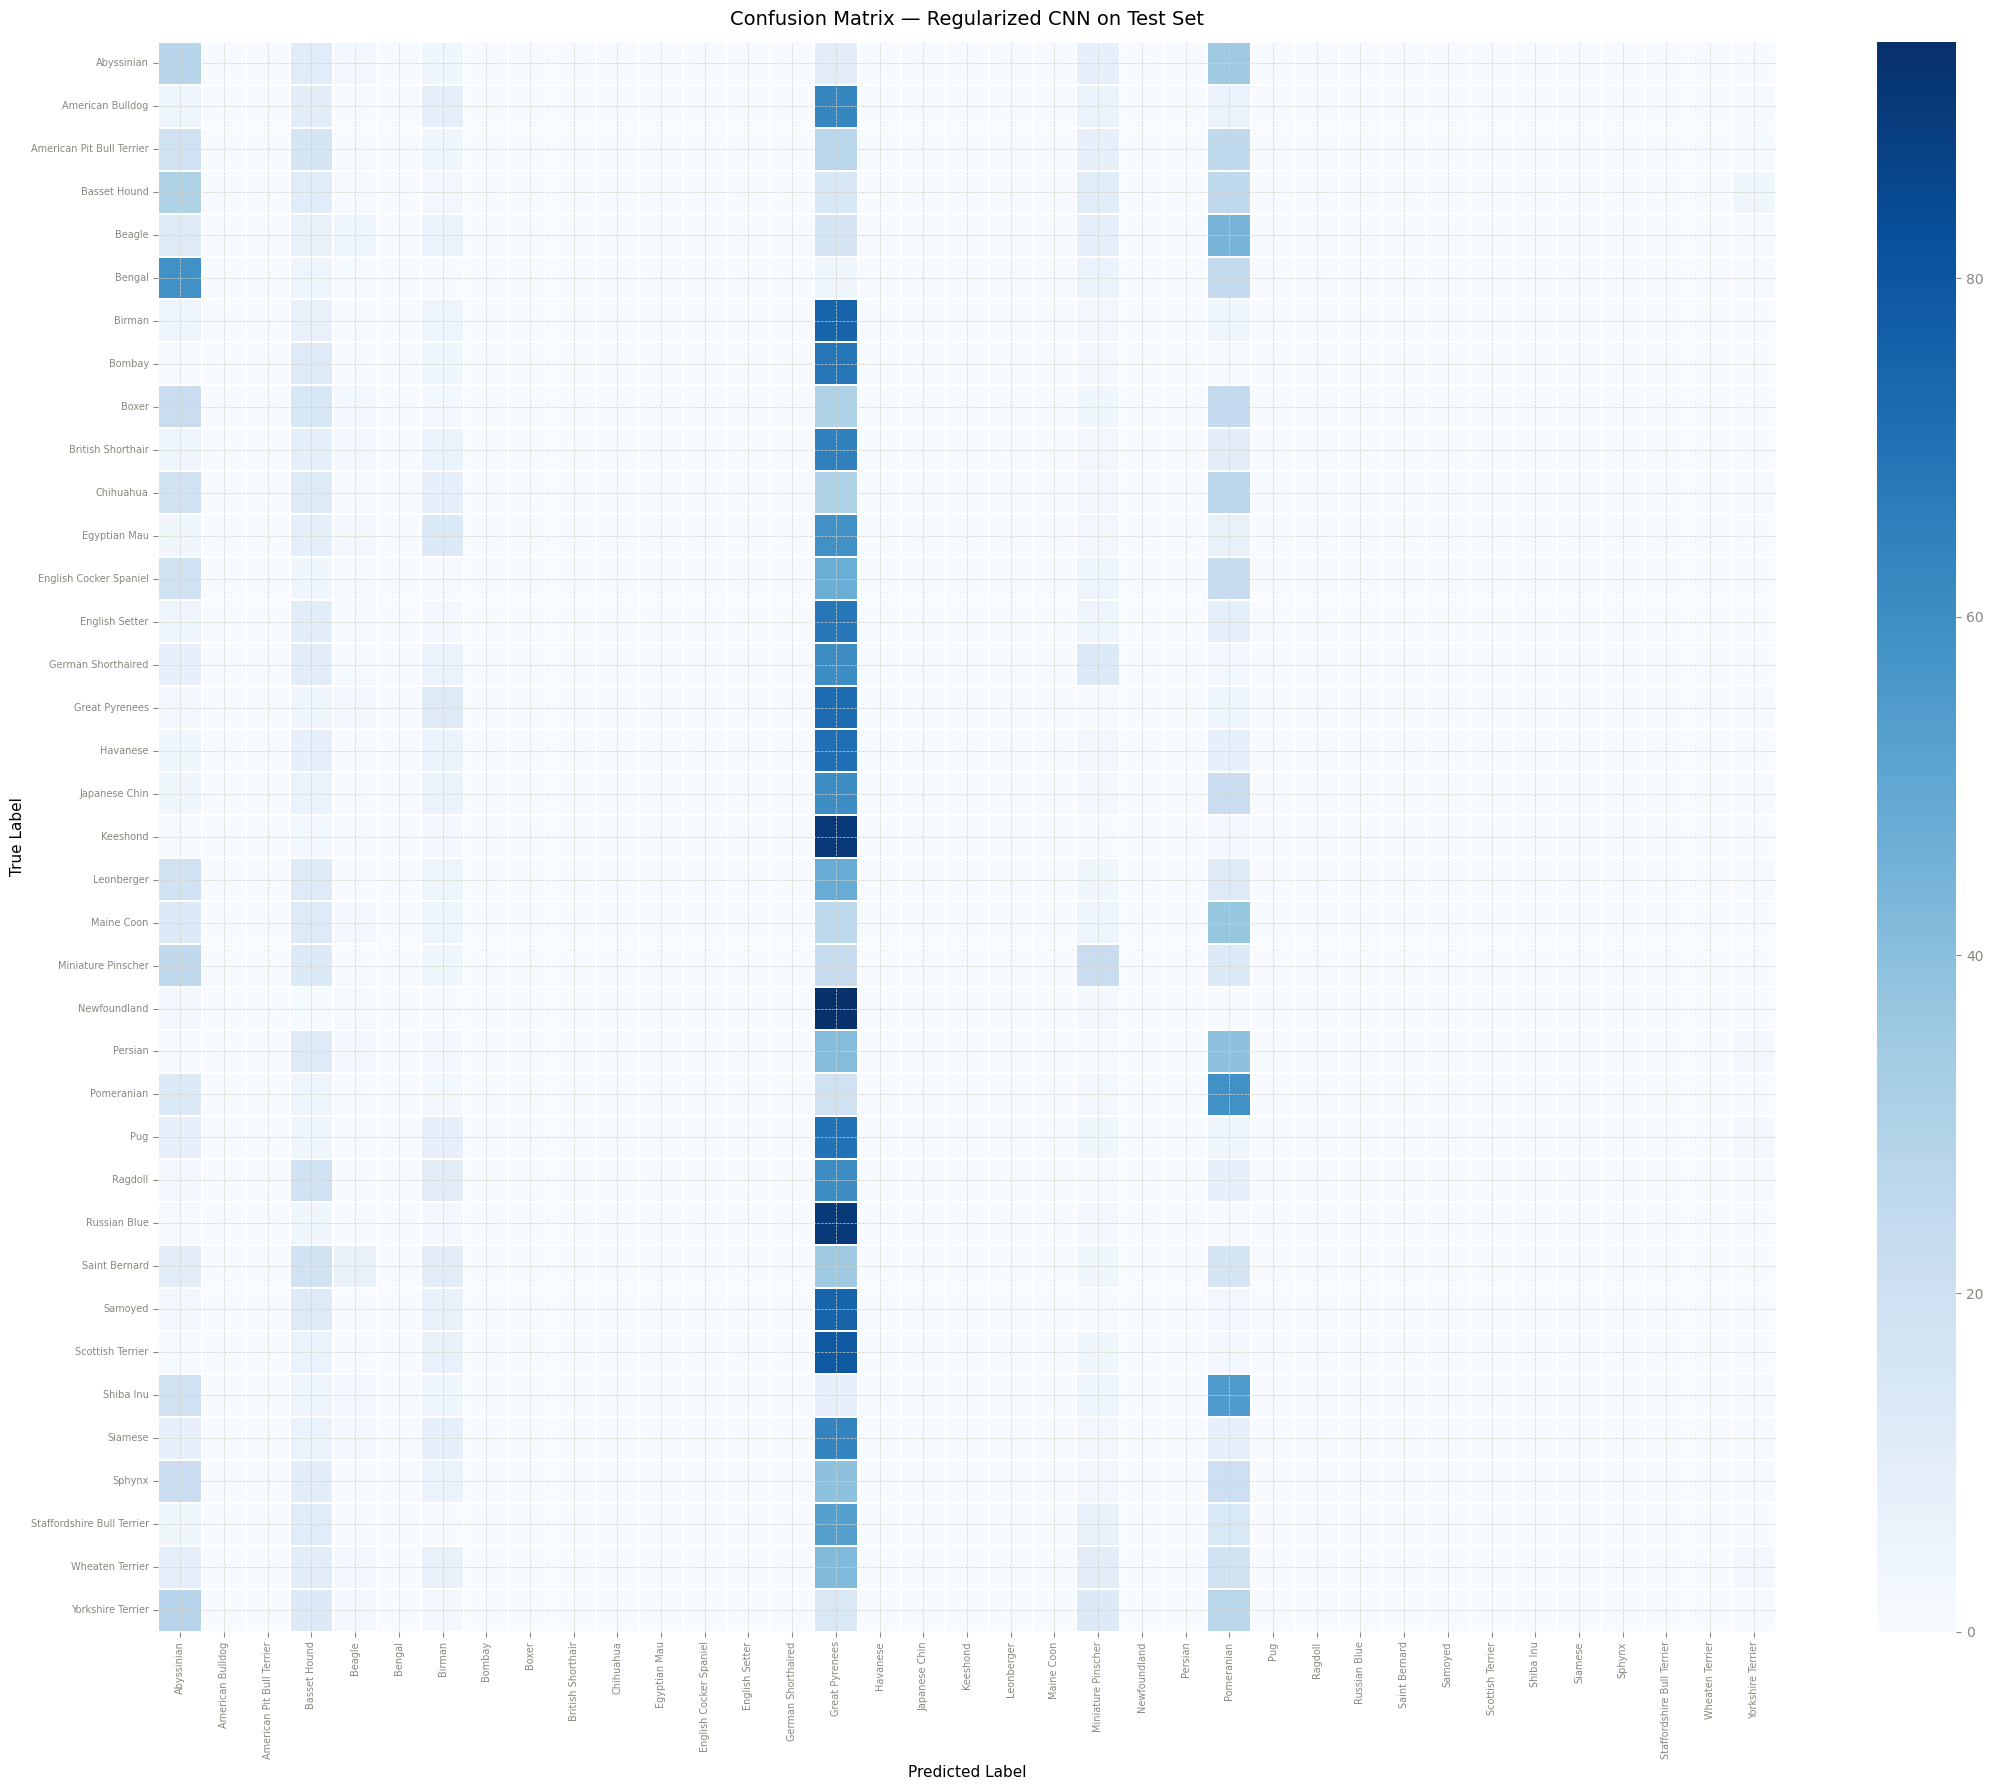

In [20]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(22, 18))
sns.heatmap(cm, xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            fmt='d', cmap='Blues', linewidths=0.3)
plt.title('Confusion Matrix — Regularized CNN on Test Set', fontsize=14, pad=12)
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label',      fontsize=11)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.savefig('confusion_matrix.pdf', bbox_inches='tight', dpi=150)
plt.show()

Top 5 Best Performing Classes:
  Great Pyrenees                : 72.0%
  Pomeranian                    : 59.0%
  Abyssinian                    : 28.6%
  Miniature Pinscher            : 22.0%
  Basset Hound                  : 11.0%

Top 5 Worst Performing Classes:
  American Bulldog              : 0.0%
  American Pit Bull Terrier     : 0.0%
  Bombay                        : 0.0%
  Bengal                        : 0.0%
  Egyptian Mau                  : 0.0%


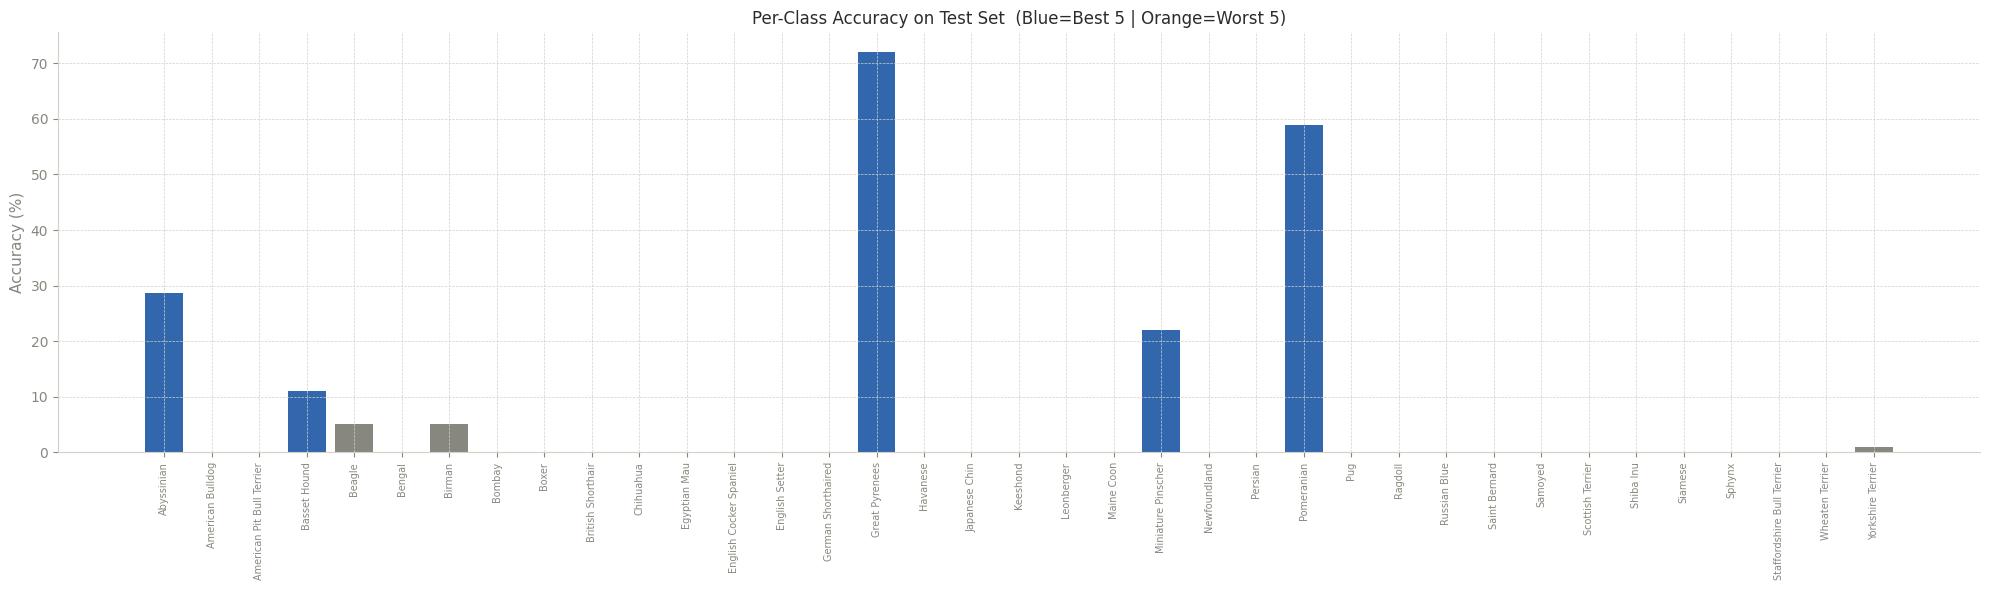

In [21]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)
sorted_idx    = np.argsort(per_class_acc)

print('Top 5 Best Performing Classes:')
for idx in sorted_idx[-5:][::-1]:
    print(f'  {CLASS_NAMES[idx]:30s}: {per_class_acc[idx]*100:.1f}%')

print('\nTop 5 Worst Performing Classes:')
for idx in sorted_idx[:5]:
    print(f'  {CLASS_NAMES[idx]:30s}: {per_class_acc[idx]*100:.1f}%')

# Bar chart — worst=ORANGE, best=BLUE, rest=GRAY
worst_set = set(sorted_idx[:5])
best_set  = set(sorted_idx[-5:])
colors    = [ORANGE if i in worst_set else BLUE if i in best_set else GRAY
             for i in range(NUM_CLASSES)]

fig, ax = plt.subplots(figsize=(20, 6))
ax.bar(range(NUM_CLASSES), per_class_acc * 100, color=colors)
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=7)
ax.set_ylabel('Accuracy (%)', color=GRAY, fontsize=11)
ax.set_title('Per-Class Accuracy on Test Set  (Blue=Best 5 | Orange=Worst 5)',
             fontsize=12, color='#2c2c2a')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('per_class_accuracy.pdf', bbox_inches='tight', dpi=150)
plt.show()

In [22]:
# Save trained model weights
torch.save(model_reg.state_dict(), 'pet_cnn_best.pth')
print("Model weights saved as 'pet_cnn_best.pth'")

# Also save base model for comparison
torch.save(model.state_dict(), 'pet_cnn_base.pth')
print("Base model saved as 'pet_cnn_base.pth'")

Model weights saved as 'pet_cnn_best.pth'
Base model saved as 'pet_cnn_base.pth'
